Default case analysis

In [1]:
%run setup.py
mdates.set_epoch('2025-01-01')
from import_data import get_data


In [2]:
filenames = [
    'case1/case1-no-ff-export.sqlite',
    'case1/one-month-timestep-no-ff-export.sqlite',
    'case1/no-behav-no-ff-export.sqlite',
]

In [3]:
# list all unphysical commodities that should be ignored
ignore_commods = ['fluorine', 'oxygen', 'extra_fluorine', 'extra_oxygen', 'silica']

In [4]:
data = {}
for file in filenames:
    (name, file_data) = get_data(file, ignore_commods)
    
    name = file.rsplit('/')[1].split('-no-ff-export.sqlite')[0]
    
    data[name] = file_data


In [5]:
data.keys()

dict_keys(['case1', 'one-month-timestep', 'no-behav'])

In [6]:
data['one-month-timestep']['transactions'].columns

Index(['SimId', 'ResourceId', 'ObjId', 'Type', 'TimeCreated', 'Quantity',
       'Units', 'QualId', 'PackageName', 'Parent1', 'Parent2', 'TransactionId',
       'SenderId', 'ReceiverId', 'Commodity', 'Time', 'SenderSpec',
       'SenderPrototype', 'ReceiverSpec', 'ReceiverPrototype',
       'SenderProtAgentId', 'ReceiverProtAgentId', 'Date',
       'CumQuantityReceived', 'CumQuantitySent', 'SSCumQuantityReceived',
       'SSCumQuantitySent'],
      dtype='object')

In [7]:
# data['one-month-timestep']['transactions'].drop(columns=['SSCumQuantityReceived','SSCumQuantitySent'], inplace=True)

In [8]:
# # steady state for month time step
# data['one-month-timestep']['transactions']['SSCumQuantityReceived'] = data[
#     'one-month-timestep']['transactions'].loc[
#         data['one-month-timestep']['transactions']['Time'] >= 25].groupby(by='ReceiverId')['Quantity'].cumsum()
# data['one-month-timestep']['transactions']['SSCumQuantitySent'] = data[
#     'one-month-timestep']['transactions'].loc[
#         data['one-month-timestep']['transactions']['Time'] >= 25].groupby(by='SenderId')['Quantity'].cumsum()

In [9]:
data.keys()

dict_keys(['case1', 'one-month-timestep', 'no-behav'])

In [10]:
data['one-month-timestep']['transactions'].columns

Index(['SimId', 'ResourceId', 'ObjId', 'Type', 'TimeCreated', 'Quantity',
       'Units', 'QualId', 'PackageName', 'Parent1', 'Parent2', 'TransactionId',
       'SenderId', 'ReceiverId', 'Commodity', 'Time', 'SenderSpec',
       'SenderPrototype', 'ReceiverSpec', 'ReceiverPrototype',
       'SenderProtAgentId', 'ReceiverProtAgentId', 'Date',
       'CumQuantityReceived', 'CumQuantitySent', 'SSCumQuantityReceived',
       'SSCumQuantitySent'],
      dtype='object')

In [11]:
# data['case1']['transactions']['Date'] = mdates.num2date(data['case1']['transactions']['Time'])
data['one-month-timestep']['transactions'].drop(columns=['Date', 'SSCumQuantityReceived', 'SSCumQuantitySent'])
data['one-month-timestep']['transactions']['Date'] = mdates.num2date(data['one-month-timestep']['transactions']['Time']*30)
startup = 25
data['one-month-timestep']['transactions']['SSCumQuantityReceived'] = data['one-month-timestep']['transactions'].sort_values(by=['Date']).loc[data['one-month-timestep']['transactions']['Time'] >= startup].groupby(by='ReceiverId')['Quantity'].cumsum()
data['one-month-timestep']['transactions']['SSCumQuantitySent'] = data['one-month-timestep']['transactions'].sort_values(by=['Date']).loc[data['one-month-timestep']['transactions']['Time'] >= startup].groupby(by='SenderId')['Quantity'].cumsum()
# data['no-behav']['transactions']['Date'] = mdates.num2date(data['no-behav']['transactions']['Time'])


In [12]:
#data['agents']['Prototype'][0:50]

In [13]:
#data['agents']['Prototype'][50:87]

In [14]:
conv_fac = []

enr_fac = ['EnrichmentReceiver',
           'EnrichmentSeparation',
           'Enrichment',
           'EnrichmentRecipeRequester',
           'EnrichmentMixer',
           'EnrichmentShipper']

enr_tails_fac = [
    'EnrichmentTailsMixer',
    'EnrichmentTailsPackager',
    'EnrichmentTailsStorage']

ff_fac = [
    'FuelFabReceiver',
    'FuelFabSeparation',
    'FuelFabMixer',
    'FuelFabShipper',
    'HALEUFuelFabReceiver',
    'HALEUFuelFabSeparation',
    'HALEUFuelFabMixer',
    'HALEUFuelFabShipper']

rx_A = [
    'RxA1Storage',
    'RxA2Storage',
    'RxA3Storage',
    'RxA4Storage',
    'RxAShipper']

rx_B = [
    'RxB1Reactor',
    'RxB2Reactor',
    'RxB3FreshFuelVault',
    'RxB3Reactor',
    'RxB4FreshFuelVault',
    'RxB4Reactor',
    'RxBBlueSpentFuelPool',
    'RxBRedSpentFuelPool']

rx_C = [
    'RxC1FreshFuelVault',
    'RxC1Reactor',
    'RxC2FreshFuelVault',
    'RxC2Reactor',
    'RxC3FreshFuelVault',
    'RxC3Reactor',
    'RxC4FreshFuelVault',
    'RxC4Reactor',
    'RxCBlueSpentFuelPool',
    'RxCRedSpentFuelPool',
    'RxCShipper']

rx_D = [
    'RxD1FreshFuelVault',
    'RxD1Reactor',
    'RxD2FreshFuelVault',
    'RxD2Reactor',
    'RxD3FreshFuelVault',
    'RxD3Reactor',
    'RxD4FreshFuelVault',
    'RxD4Reactor',
    'RxDBlueSpentFuelPool',
    'RxDRedSpentFuelPool',
    'RxDShipper']
   

In [15]:
enr_fac[0]

'EnrichmentReceiver'

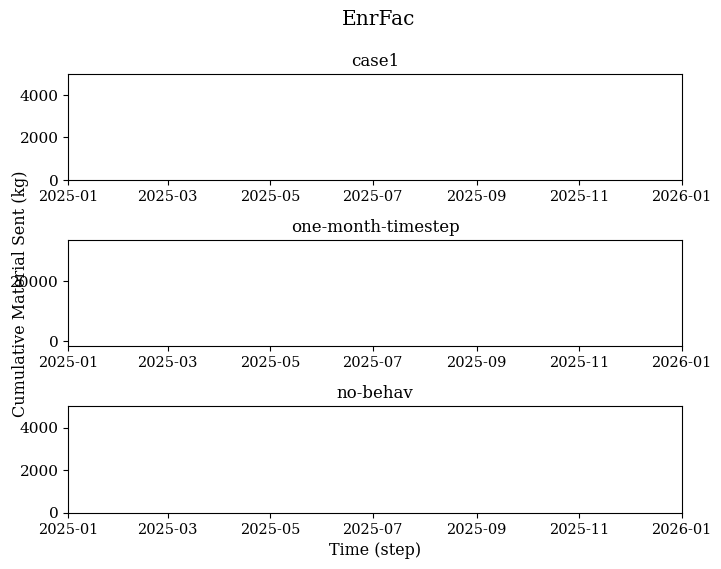

In [16]:
c1 = data['case1']['transactions'].loc[data['case1']['transactions']['SenderPrototype'] == ff_fac[3]]
om = data['one-month-timestep']['transactions'].loc[data['one-month-timestep']['transactions']['SenderPrototype'] == ff_fac[3]]
nobhv = data['no-behav']['transactions'].loc[data['no-behav']['transactions']['SenderPrototype'] == ff_fac[3]]

fig = plt.figure(figsize = (8, 6))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Sent (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(311)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
ax0.set_xlim([0,1*365])
# ax0.set_xticks(np.arange(0, 50, 7))
ax0.set_ylim([0,5e3])
# ax0.set_yticks(np.arange(0, 25, 5))

ax0.step(c1['Date'],
         c1['Quantity'],
         color= palette[0])
ax0.set_title('case1')

###

ax1 = fig.add_subplot(312, sharex=ax0)
ax1.step(om['Date'],
         om['Quantity'],
         color= palette[1])
ax1.set_title('one-month-timestep')

###

ax2 = fig.add_subplot(313, sharex=ax0, sharey=ax0)
ax2.step(nobhv['Date'],
         nobhv['Quantity'],
         color= palette[2])
ax2.set_title('no-behav')


fig.suptitle('EnrFac', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


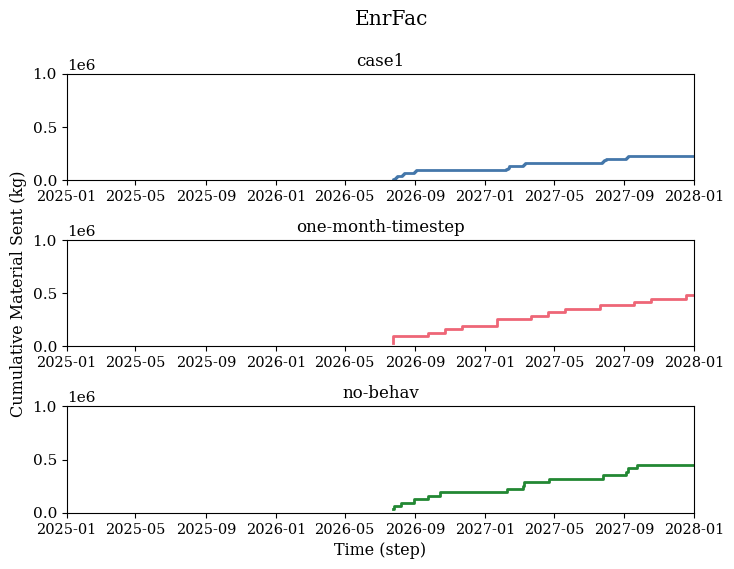

In [17]:
c1 = data['case1']['transactions'].loc[data['case1']['transactions']['SenderPrototype'] == ff_fac[3]]
om = data['one-month-timestep']['transactions'].loc[data['one-month-timestep']['transactions']['SenderPrototype'] == ff_fac[3]]
nobhv = data['no-behav']['transactions'].loc[data['no-behav']['transactions']['SenderPrototype'] == ff_fac[3]]

fig = plt.figure(figsize = (8, 6))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Sent (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(311)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
ax0.set_xlim([0,3*365])
# ax0.set_xticks(np.arange(0, 50, 7))
ax0.set_ylim([0,1e6])
# ax0.set_yticks(np.arange(0, 25, 5))

ax0.step(c1['Date'],
         c1['CumQuantitySent'],
         color= palette[0])
ax0.set_title('case1')

###

ax1 = fig.add_subplot(312, sharex=ax0, sharey=ax0)
ax1.step(om['Date'],
         om['CumQuantitySent'],
         color= palette[1])
ax1.set_title('one-month-timestep')

###

ax2 = fig.add_subplot(313, sharex=ax0, sharey=ax0)
ax2.step(nobhv['Date'],
         nobhv['CumQuantitySent'],
         color= palette[2])
ax2.set_title('no-behav')


fig.suptitle('EnrFac', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


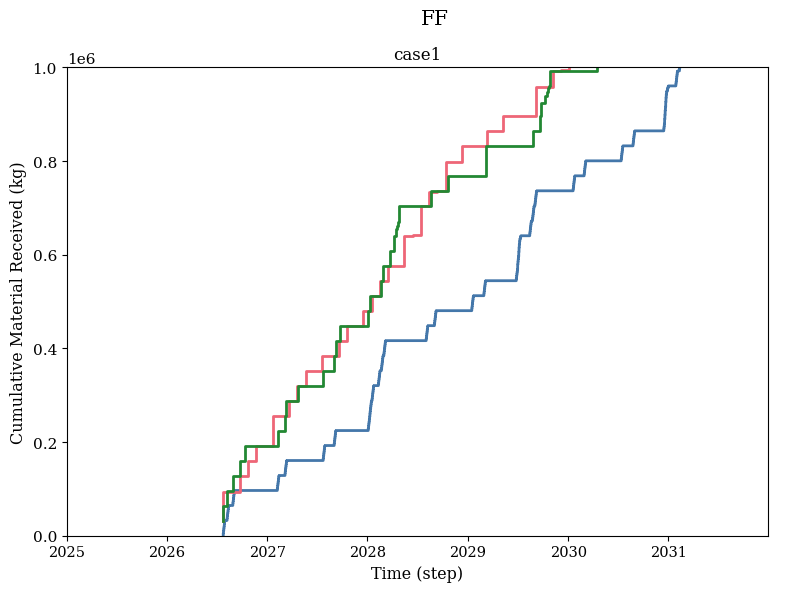

In [18]:
c1 = data['case1']['transactions'].loc[data['case1']['transactions']['SenderPrototype'] == ff_fac[3]]
om = data['one-month-timestep']['transactions'].loc[data['one-month-timestep']['transactions']['SenderPrototype'] == ff_fac[3]]
nobhv = data['no-behav']['transactions'].loc[data['no-behav']['transactions']['SenderPrototype'] == ff_fac[3]]

fig = plt.figure(figsize = (8, 6))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(111)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
ax0.set_xlim([0,7*365])
# ax0.set_xticks(np.arange(0, 50, 7))
ax0.set_ylim([0,1e6])
# ax0.set_yticks(np.arange(0, 25, 5))

ax0.step(c1['Date'],
         c1['CumQuantitySent'],
         color= palette[0])
ax0.set_title('case1')

###

ax0.step(om['Date'],
         om['CumQuantitySent'],
         color= palette[1])

###

ax0.step(nobhv['Date'],
         nobhv['CumQuantitySent'],
         color= palette[2])


fig.suptitle('FF', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [19]:
data['one-month-timestep']['transactions']['SSCumQuantitySent']

4                NaN
5                NaN
7                NaN
8                NaN
10               NaN
            ...     
9307    1.905871e+07
9308    2.687400e+02
9309    1.565675e+06
9296    1.765127e+06
9311    1.885257e+06
Name: SSCumQuantitySent, Length: 9133, dtype: float64

In [20]:
data['one-month-timestep']['transactions'].loc[data['one-month-timestep']['transactions']['SenderPrototype'] == ff_fac[3]].loc[
data['one-month-timestep']['transactions'].loc[data['one-month-timestep']['transactions']['SenderPrototype'] == ff_fac[3]]['SSCumQuantitySent'] > 0].iloc[0]

SimId                    12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f
ResourceId                                              16317
ObjId                                                   11352
Type                                                 Material
TimeCreated                                                25
Quantity                                              31990.4
Units                                                      kg
QualId                                                   2016
PackageName                                        unpackaged
Parent1                                                 16163
Parent2                                                     0
TransactionId                                            2409
SenderId                                                  133
ReceiverId                                                223
Commodity                                          LEUO2_fuel
Time                                                       25
SenderSp

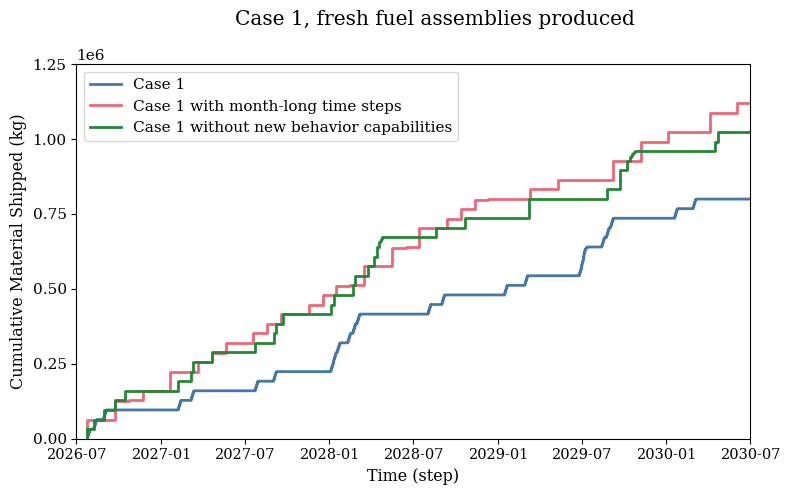

In [21]:
c1 = data['case1']['transactions'].loc[data['case1']['transactions']['SenderPrototype'] == ff_fac[3]]
om = data['one-month-timestep']['transactions'].loc[data['one-month-timestep']['transactions']['SenderPrototype'] == ff_fac[3]]
nobhv = data['no-behav']['transactions'].loc[data['no-behav']['transactions']['SenderPrototype'] == ff_fac[3]]


fig = plt.figure(figsize = (8, 5))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(111)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
ss_start = 546
ax0.set_xlim([ss_start,ss_start+(4)*365+1])
# ax0.set_xticks(np.arange(0, 50, 7))
maxy=1.25e6
ax0.set_ylim([0,maxy])
ax0.set_yticks(np.arange(0, maxy+1, maxy/5))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax0.step(c1['Date'],
         c1['Quantity'].cumsum(),
         color= palette[0],
        label='Case 1',
        where='post')
# ax0.set_title('case1')

###

ax0.step(om['Date'],
         om['Quantity'].cumsum(),
         color= palette[1],
         label='Case 1 with month-long time steps',
        where='post')
ax0.vlines(x=om.loc[om['CumQuantitySent'] > 0].iloc[0]['Date'],ymin=0,ymax=om.loc[om['CumQuantitySent'] > 0].iloc[0]['CumQuantitySent'], color=palette[1])
# ax0.set_title('one-month-timestep')

###

ax0.step(nobhv['Date'],
         nobhv['Quantity'].cumsum(),
         color= palette[2],
         label='Case 1 without new behavior capabilities',
        where='post')
ax0.vlines(x=nobhv.loc[nobhv['CumQuantitySent'] > 0].iloc[0]['Date'],ymin=0,
           ymax=nobhv.loc[nobhv['CumQuantitySent'] > 0].iloc[0]['CumQuantitySent'], color=palette[2])
# ax2.set_title('no-behav')

ax0.set_ylabel('Cumulative Material Shipped (kg)')



fig.suptitle('Case 1, fresh fuel assemblies produced', x=0.55)
fig.tight_layout()
ax0.legend()

plt.savefig('plots/c1_demo_comparison', transparent=True)


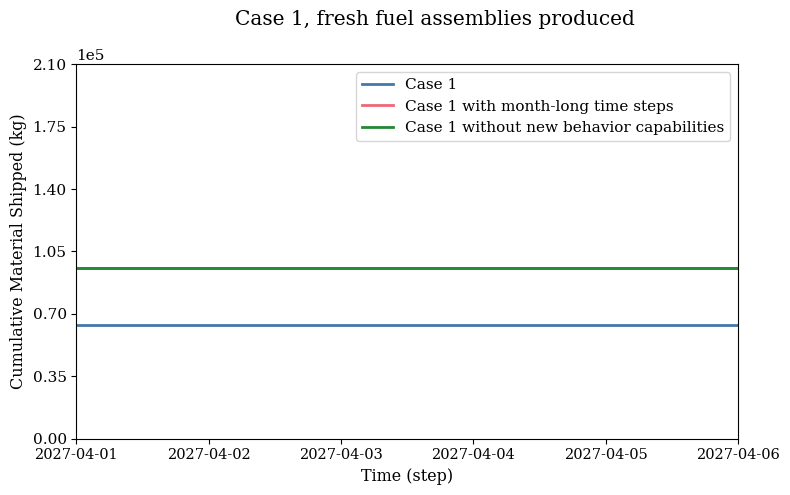

In [22]:
c1 = data['case1']['transactions'].loc[data['case1']['transactions']['SenderPrototype'] == ff_fac[3]]
om = data['one-month-timestep']['transactions'].loc[data['one-month-timestep']['transactions']['SenderPrototype'] == ff_fac[3]]
nobhv = data['no-behav']['transactions'].loc[data['no-behav']['transactions']['SenderPrototype'] == ff_fac[3]]

fig = plt.figure(figsize = (8, 5))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(111)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
ss_start = 820
ax0.set_xlim([ss_start,ss_start+5])#ss_start+(1/12)*365+1])
# ax0.set_xticks(np.arange(0, 50, 7))
maxy=2.1e5
ax0.set_ylim([0,maxy])
ax0.set_yticks(np.arange(0, maxy+1, maxy/6))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax0.step(c1['Date'],
         c1['SSCumQuantitySent'],
         color= palette[0],
        label='Case 1',
        where='post')
# ax0.set_title('case1')

###

ax0.step(om['Date'],
         om['SSCumQuantitySent'],
         color= palette[1],
         label='Case 1 with month-long time steps',
        where='post')
ax0.vlines(x=om.loc[om['SSCumQuantitySent'] > 0].iloc[0]['Date'],ymin=0,ymax=om.loc[om['SSCumQuantitySent'] > 0].iloc[0]['SSCumQuantitySent'], color=palette[1])
# ax0.set_title('one-month-timestep')

###

ax0.step(nobhv['Date'],
         nobhv['SSCumQuantitySent'],
         color= palette[2],
         label='Case 1 without new behavior capabilities',
        where='post')
# ax2.set_title('no-behav')

ax0.set_ylabel('Cumulative Material Shipped (kg)')



fig.suptitle('Case 1, fresh fuel assemblies produced', x=0.55)
fig.tight_layout()
ax0.legend()

plt.savefig('plots/c1_demo_comparison_severaldaysonly', transparent=True)


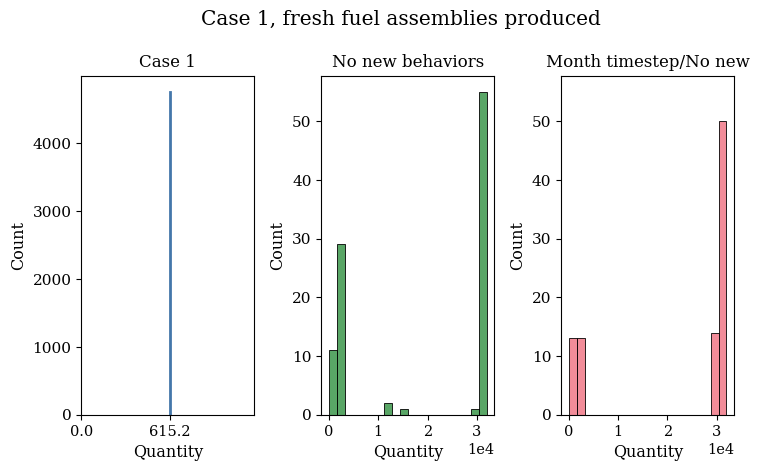

In [23]:
c1 = data['case1']['transactions'].loc[data['case1']['transactions']['SenderPrototype'] == ff_fac[3]]
om = data['one-month-timestep']['transactions'].loc[data['one-month-timestep']['transactions']['SenderPrototype'] == ff_fac[3]]
nobhv = data['no-behav']['transactions'].loc[data['no-behav']['transactions']['SenderPrototype'] == ff_fac[3]]


fig = plt.figure(figsize = (8, 5))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
# ax.set_xlabel('Time (step)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(131)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# ss_start = 600

# ax0.set_xticks(np.arange(0, 50, 7))
# maxy=0.5e6
# ax0.set_ylim([0,maxy])
# ax0.set_yticks(np.arange(0, maxy+1, maxy/6))
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

sns.histplot(c1['Quantity'],
         color= palette[0],
        label='Case 1',
        ax=ax0,
            kde=True)
ax0.set_title('Case 1')

ax0.set_xlim([0,1200])
ax0.set_xticks(np.arange(0, 1201, 615.2))

###
ax2 = fig.add_subplot(132)
sns.histplot(nobhv['Quantity'],
         color= palette[2],
         label='Case 1 without new behavior capabilities',
        ax=ax2,
            bins=20)
ax2.set_title('No new behaviors')
ax2.set_xticks(np.arange(0, 30001, 10000))
ax2.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# ax0.set_ylabel('Cumulative Material Shipped (kg)')

###
ax1 = fig.add_subplot(133, sharey=ax2)
sns.histplot(om['Quantity'],
         color= palette[1],
         label='Case 1 with month-long time steps',
        ax=ax1,
            bins=20)
# ax0.vlines(x=om.loc[om['SSCumQuantitySent'] > 0].iloc[0]['Date'],ymin=0,ymax=om.loc[om['SSCumQuantitySent'] > 0].iloc[0]['SSCumQuantitySent'], color=palette[1])
ax1.set_title('Month timestep/No new')
ax1.set_xticks(np.arange(0, 30001, 10000))
ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))





fig.suptitle('Case 1, fresh fuel assemblies produced', x=0.55)
fig.tight_layout()
# ax0.legend()

plt.savefig('plots/c1_demo_comparison_hist', transparent=True)


<AxesSubplot:xlabel='Quantity', ylabel='Count'>

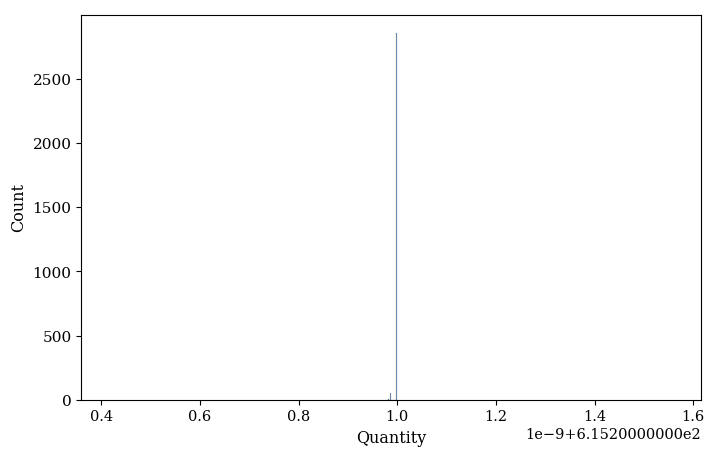

In [24]:

fig = plt.figure(figsize = (8, 5))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
# ax.set_xlabel('Time (step)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(111)

sns.histplot(c1['Quantity'],
         color= palette[0],
        label='Case 1',)

In [25]:
data['case1']['agents'].loc[data['case1']['agents']['Prototype'] == rx_C[0]]['AgentId'].iloc[0]

216

In [26]:
data['case1']['ei'].loc[data['case1']['ei']['AgentId'] == data['case1']['agents'].loc[data['case1']['agents']['Prototype'] == rx_C[0]]['AgentId'].iloc[0]]

,SimId,AgentId,Time,InventoryName,NucId,Quantity,Units
60079,166905d5-afe5-463d-ab01-d1545e168dc0,216,605,stocks,80160000,5.832096e+02,kg
60080,166905d5-afe5-463d-ab01-d1545e168dc0,216,605,stocks,922350000,1.952264e+02,kg
60081,166905d5-afe5-463d-ab01-d1545e168dc0,216,605,stocks,922380000,4.143164e+03,kg
60198,166905d5-afe5-463d-ab01-d1545e168dc0,216,606,stocks,80160000,1.166419e+03,kg
60199,166905d5-afe5-463d-ab01-d1545e168dc0,216,606,stocks,922350000,3.904531e+02,kg
...,...,...,...,...,...,...,...
700095,166905d5-afe5-463d-ab01-d1545e168dc0,216,3648,stocks,922350000,1.237153e-08,kg
700096,166905d5-afe5-463d-ab01-d1545e168dc0,216,3648,stocks,922380000,2.625537e-07,kg
700312,166905d5-afe5-463d-ab01-d1545e168dc0,216,3649,stocks,80160000,3.695819e-08,kg
700313,166905d5-afe5-463d-ab01-d1545e168dc0,216,3649,stocks,922350000,1.237153e-08,kg


In [27]:
mdates.num2date(data['case1']['ei'].loc[
    data['case1']['ei']['AgentId'] == data['case1']['agents'].loc[data['case1']['agents']['Prototype'] == rx_C[0]]['AgentId'].iloc[0]
].groupby('Time')['Quantity'].sum().reset_index()['Time'])

[datetime.datetime(2026, 8, 29, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 8, 30, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 8, 31, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 1, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 2, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 3, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 4, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 5, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 6, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 7, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 8, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 9, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 10, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 11, 0, 0, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 12, 0, 0, tzinf

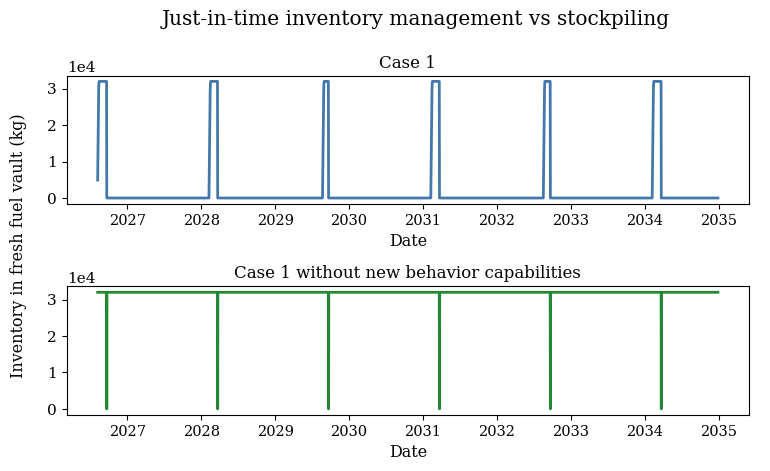

In [28]:
c1 = data['case1']['ei'].loc[
    data['case1']['ei']['AgentId'] == data['case1']['agents'].loc[data['case1']['agents']['Prototype'] == rx_B[4]]['AgentId'].iloc[0]
].groupby('Time')['Quantity'].sum().reset_index()
c1['Date'] = mdates.num2date(c1['Time'])

nobhv = data['no-behav']['ei'].loc[
    data['no-behav']['ei']['AgentId'] == data['no-behav']['agents'].loc[data['no-behav']['agents']['Prototype'] == rx_B[4]]['AgentId'].iloc[0]
].groupby('Time')['Quantity'].sum().reset_index()
nobhv['Date'] = mdates.num2date(nobhv['Time'])

fig = plt.figure(figsize = (8, 5))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)

# ax.set_xlabel('Time (step)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

###

ax0 = fig.add_subplot(211)

sns.lineplot(x=c1['Date'],
             y=c1['Quantity'],
         color= palette[0],
        # label='Case 1',
            ax=ax0)


# ax0.set_xticks(np.arange(0, 4000, 100))
# ax0.set_xlim([1700,1800])

ax0.set_title('Case 1')
# ax0.set_xlabel('Date')
ax0.set_ylabel('')
ax0.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax1 = fig.add_subplot(212, sharex=ax0, sharey=ax0)

sns.lineplot(x=nobhv['Date'],
             y=nobhv['Quantity'],
         color= palette[2],
        # label='no-behav',
            ax=ax1)

ax1.set_title('Case 1 without new behavior capabilities')
ax1.set_ylabel('')

ax.set_ylabel('Inventory in fresh fuel vault (kg)')

fig.suptitle('Just-in-time inventory management vs stockpiling', x=0.55)

fig.tight_layout()

plt.savefig('plots/c1_demo_comparison_FFV', transparent=True)

In [29]:
import cymetric as cym

In [30]:
TimeSeriesdemandLEUF6 = cym.root_metric(name='TimeSeriesdemandLEUF6')
TimeSeriessupplyLEUF6 = cym.root_metric(name='TimeSeriessupplyLEUF6')

In [31]:
# data['case1']['rx_events'] = data['case1']['ev'].eval("ReactorEvents")
c1_rxs = data['case1']['rx_events']['AgentId'].unique()
c1_rxs

array([158, 160, 162, 201, 203, 205, 207, 209, 211, 213, 219, 220, 222])

In [32]:
data['case1']['agents'].loc[data['case1']['agents']['Spec'] == ':cycamore:Reactor']

,SimId,AgentId,Kind,Spec,Prototype,ParentId,Lifetime,EnterTime,ExitTime
47,166905d5-afe5-463d-ab01-d1545e168dc0,158,Facility,:cycamore:Reactor,ResearchReactor3,112,-1,0,3650.0
49,166905d5-afe5-463d-ab01-d1545e168dc0,160,Facility,:cycamore:Reactor,ResearchReactor4,112,-1,0,3650.0
51,166905d5-afe5-463d-ab01-d1545e168dc0,162,Facility,:cycamore:Reactor,ResearchReactor5,112,-1,0,3650.0
59,166905d5-afe5-463d-ab01-d1545e168dc0,201,Facility,:cycamore:Reactor,RxD1Reactor,167,-1,88,3650.0
61,166905d5-afe5-463d-ab01-d1545e168dc0,203,Facility,:cycamore:Reactor,RxB4Reactor,167,-1,102,3650.0
63,166905d5-afe5-463d-ab01-d1545e168dc0,205,Facility,:cycamore:Reactor,RxC1Reactor,167,-1,123,3650.0
65,166905d5-afe5-463d-ab01-d1545e168dc0,207,Facility,:cycamore:Reactor,RxD2Reactor,167,-1,285,3650.0
67,166905d5-afe5-463d-ab01-d1545e168dc0,209,Facility,:cycamore:Reactor,RxC2Reactor,167,-1,313,3650.0
69,166905d5-afe5-463d-ab01-d1545e168dc0,211,Facility,:cycamore:Reactor,RxC3Reactor,167,-1,452,3650.0
71,166905d5-afe5-463d-ab01-d1545e168dc0,213,Facility,:cycamore:Reactor,RxD3Reactor,167,-1,492,3650.0


In [33]:
c1rx3 = data['case1']['rx_events'].loc[data['case1']['rx_events']['AgentId'] == c1_rxs[3]]
c1rx3.head(10)

,SimId,AgentId,Time,Event,Value
26,166905d5-afe5-463d-ab01-d1545e168dc0,201,88,LOAD,156 assemblies
27,166905d5-afe5-463d-ab01-d1545e168dc0,201,88,CYCLE_START,
115,166905d5-afe5-463d-ab01-d1545e168dc0,201,615,TRANSMUTE,52 assemblies
116,166905d5-afe5-463d-ab01-d1545e168dc0,201,615,CYCLE_END,
117,166905d5-afe5-463d-ab01-d1545e168dc0,201,615,DISCHARGE,52 assemblies
118,166905d5-afe5-463d-ab01-d1545e168dc0,201,615,LOAD,52 assemblies
132,166905d5-afe5-463d-ab01-d1545e168dc0,201,636,CYCLE_START,
254,166905d5-afe5-463d-ab01-d1545e168dc0,201,1163,TRANSMUTE,52 assemblies
255,166905d5-afe5-463d-ab01-d1545e168dc0,201,1163,CYCLE_END,
256,166905d5-afe5-463d-ab01-d1545e168dc0,201,1163,DISCHARGE,52 assemblies


In [34]:
c1rx3['TimeDiff'] = c1rx3['Time'].diff()
c1rx3.head(10)

/tmp/ipykernel_94017/1762114614.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c1rx3['TimeDiff'] = c1rx3['Time'].diff()


,SimId,AgentId,Time,Event,Value,TimeDiff
26,166905d5-afe5-463d-ab01-d1545e168dc0,201,88,LOAD,156 assemblies,NaN
27,166905d5-afe5-463d-ab01-d1545e168dc0,201,88,CYCLE_START,,0.0
115,166905d5-afe5-463d-ab01-d1545e168dc0,201,615,TRANSMUTE,52 assemblies,527.0
116,166905d5-afe5-463d-ab01-d1545e168dc0,201,615,CYCLE_END,,0.0
117,166905d5-afe5-463d-ab01-d1545e168dc0,201,615,DISCHARGE,52 assemblies,0.0
118,166905d5-afe5-463d-ab01-d1545e168dc0,201,615,LOAD,52 assemblies,0.0
132,166905d5-afe5-463d-ab01-d1545e168dc0,201,636,CYCLE_START,,21.0
254,166905d5-afe5-463d-ab01-d1545e168dc0,201,1163,TRANSMUTE,52 assemblies,527.0
255,166905d5-afe5-463d-ab01-d1545e168dc0,201,1163,CYCLE_END,,0.0
256,166905d5-afe5-463d-ab01-d1545e168dc0,201,1163,DISCHARGE,52 assemblies,0.0


In [35]:
data['case1']['rx_events']['TimeDiff'] = data['case1']['rx_events'].groupby(by='AgentId')['Time'].diff()

In [36]:
data['case1']['rx_events'].loc[data['case1']['rx_events']['AgentId'] == 221]

,SimId,AgentId,Time,Event,Value,TimeDiff


In [37]:
rx_C

['RxC1FreshFuelVault',
 'RxC1Reactor',
 'RxC2FreshFuelVault',
 'RxC2Reactor',
 'RxC3FreshFuelVault',
 'RxC3Reactor',
 'RxC4FreshFuelVault',
 'RxC4Reactor',
 'RxCBlueSpentFuelPool',
 'RxCRedSpentFuelPool',
 'RxCShipper']

In [38]:
c1 = data['case1']['transactions'].loc[
    (data['case1']['transactions']['SenderPrototype'] == ff_fac[3]) &
    (data['case1']['transactions']['ReceiverPrototype'] == rx_C[0])]

In [39]:
om[['Quantity','Date']]

,Quantity,Date
1522,31989.8,2026-07-25 00:00:00+00:00
1521,31991.0,2026-07-25 00:00:00+00:00
2126,29809.6,2026-09-23 00:00:00+00:00
2125,31990.4,2026-09-23 00:00:00+00:00
2300,1566.8,2026-10-23 00:00:00+00:00
...,...,...
8915,2180.8,2034-05-14 00:00:00+00:00
8950,29809.6,2034-06-13 00:00:00+00:00
8951,2180.8,2034-06-13 00:00:00+00:00
9299,31990.4,2034-09-11 00:00:00+00:00


In [40]:
data['one-month-timestep']['agents'].loc[data['one-month-timestep']['agents']['Prototype'] == rx_C[1]]['AgentId'].iloc[0]

205

In [41]:
data['one-month-timestep']['rx_events'].loc[data['one-month-timestep']['rx_events']['AgentId'] ==
    data['one-month-timestep']['agents'].loc[data['one-month-timestep']['agents']['Prototype'] == rx_C[1]]['AgentId'].iloc[0]]

,SimId,AgentId,Time,Event,Value
4,12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f,205,4,LOAD,156 assemblies
5,12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f,205,4,CYCLE_START,
77,12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f,205,21,TRANSMUTE,52 assemblies
78,12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f,205,21,CYCLE_END,
79,12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f,205,21,DISCHARGE,52 assemblies
98,12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f,205,24,LOAD,52 assemblies
100,12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f,205,24,CYCLE_START,
197,12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f,205,41,TRANSMUTE,52 assemblies
198,12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f,205,41,CYCLE_END,
199,12ee4ac2-4bfb-48e6-9adb-161fbbb91e9f,205,41,DISCHARGE,52 assemblies


In [47]:
data['case1']['ev'].eval('TimeSeriesPower').groupby('Time')['Value'].sum().reset_index()

,Time,Value
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0
...,...,...
3645,3645,10000.0
3646,3646,10000.0
3647,3647,10000.0
3648,3648,10000.0


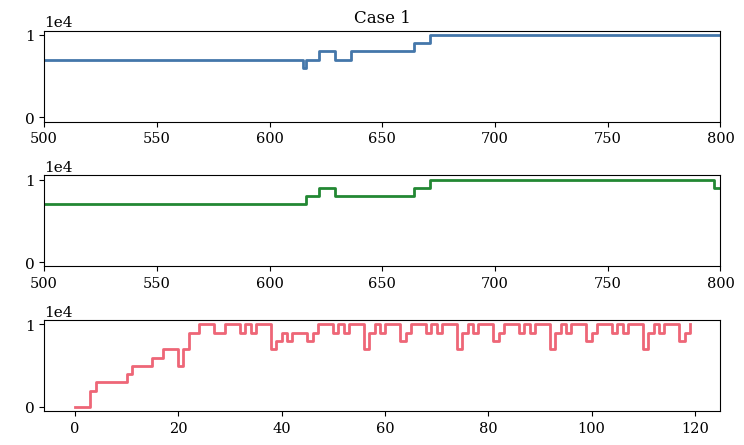

In [66]:


fig = plt.figure(figsize = (8, 5))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)

# ax.set_xlabel('Time (step)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

###

ax0 = fig.add_subplot(311)

ax0.step(x=data['case1']['ev'].eval('TimeSeriesPower').groupby('Time')['Value'].sum().reset_index()['Time'],
         y=data['case1']['ev'].eval('TimeSeriesPower').groupby('Time')['Value'].sum().reset_index()['Value'],
         color= palette[0],
         where='post')


# ax0.set_xticks(np.arange(0, 4000, 100))


ax0.set_title('Case 1')
# ax0.set_xlabel('Date')
ax0.set_ylabel('')
ax0.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax0.set_xlim([500,800])

ax1 = fig.add_subplot(312, sharex=ax0, sharey=ax0)

ax1.step(x=data['no-behav']['ev'].eval('TimeSeriesPower').groupby('Time')['Value'].sum().reset_index()['Time'],
         y=data['no-behav']['ev'].eval('TimeSeriesPower').groupby('Time')['Value'].sum().reset_index()['Value'],
         where='post',
         color= palette[2])

ax2 = fig.add_subplot(313, sharey=ax0)

ax2.step(x=data['one-month-timestep']['ev'].eval('TimeSeriesPower').groupby('Time')['Value'].sum().reset_index()['Time'],
         y=data['one-month-timestep']['ev'].eval('TimeSeriesPower').groupby('Time')['Value'].sum().reset_index()['Value'],
         where='post',
         color= palette[1])

ax1.set_title('')
ax1.set_ylabel('')

ax.set_ylabel('')

fig.suptitle('', x=0.55)

fig.tight_layout()

plt.savefig('plots/c1_demo_comparison_FFV', transparent=True)

In [67]:
data['no-behav']['ev'].eval('TimeSeriesPower').loc[
    (data['no-behav']['ev'].eval('TimeSeriesPower')['Time'] > 600) & 
    (data['no-behav']['ev'].eval('TimeSeriesPower')['Time'] < 650)]

,SimId,AgentId,Time,Value,Units
4155,0ac7d48d-0f9f-49e0-a3a0-1780c63570de,158,601,0.0,
4156,0ac7d48d-0f9f-49e0-a3a0-1780c63570de,160,601,0.0,
4157,0ac7d48d-0f9f-49e0-a3a0-1780c63570de,162,601,0.0,
4158,0ac7d48d-0f9f-49e0-a3a0-1780c63570de,201,601,1000.0,
4159,0ac7d48d-0f9f-49e0-a3a0-1780c63570de,203,601,1000.0,
...,...,...,...,...,...
4702,0ac7d48d-0f9f-49e0-a3a0-1780c63570de,209,649,1000.0,
4703,0ac7d48d-0f9f-49e0-a3a0-1780c63570de,211,649,1000.0,
4704,0ac7d48d-0f9f-49e0-a3a0-1780c63570de,213,649,1000.0,
4705,0ac7d48d-0f9f-49e0-a3a0-1780c63570de,219,649,1000.0,
